# Batch Audio Inference with Fine-Tuned SpeechBrain Model

This notebook demonstrates how to perform batch inference on a directory of audio files using the fine-tuned SpeechBrain model.

## Features:
- Load fine-tuned model
- Process entire directories of audio files
- Store probability vectors for each file
- Save results in multiple formats (CSV, NumPy, JSON)

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from batch_inference import BatchAudioInference, load_results

## 1. Configuration

Set up paths and parameters for inference.

In [38]:
# Model paths
PRETRAINED_MODEL_PATH = "pretrained_urbansound8k"
FINE_TUNED_WEIGHTS_PATH = "fine_tuned_urbansound8k_8class.pth"

# Input/Output paths
INPUT_DIR = "D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/audio_chunks"  # Directory with audio files to process
OUTPUT_DIR = "inference_results"  # Where to save results

# Model configuration
NUM_CLASSES = 8
CLASS_NAMES = [
    "crowd-noise",
    "generator",
    "motorvehicle-horn",
    "mobile-music",
    "community-radio",
    "construction-site",
    "motorvehicle-siren",
    "car-alarm"
]  # Update with your actual class names

# Processing parameters
BATCH_SIZE = 8
SAMPLE_RATE = 16000
MAX_LENGTH = 160000  # 10 seconds at 16kHz

## 2. Initialize Batch Processor

Create the batch inference processor with the fine-tuned model.

In [39]:
processor = BatchAudioInference(
    pretrained_model_path=PRETRAINED_MODEL_PATH,
    fine_tuned_weights_path=FINE_TUNED_WEIGHTS_PATH,
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    sample_rate=SAMPLE_RATE,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE
)

print("✅ Batch processor initialized successfully!")

D:\Projects\UrbanNoiseClassifier\project\audio-classifier\speechbrain-classifier\speechbrain\speechbrain\utils\parameter_transfer.py:234: UserWarning: Requested Pretrainer collection using symlinks on Windows. This might not work; see `LocalStrategy` documentation. Consider unsetting `collect_in` in Pretrainer to avoid symlinking altogether.
  warnings.warn(


✅ Batch processor initialized successfully!


## 3. Process Directory of Audio Files

Run inference on all audio files in the specified directory.

In [40]:
# Process all audio files
results_df = processor.process_directory(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    save_format='both'  # Save both CSV and NumPy formats
)

print(f"\n✅ Processed {len(results_df)} audio files")
print("\nFirst few results:")
results_df.head()

Found 120 audio files in D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/audio_chunks


Processing batches:   0%|          | 0/15 [00:00<?, ?it/s]d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: 

✅ Saved CSV results to: inference_results\inference_results_20251029_230714.csv
✅ Saved probability vectors to: inference_results\probability_vectors_20251029_230714.npy
✅ Saved metadata to: inference_results\metadata_20251029_230714.json

✅ Processed 120 audio files

First few results:


,filename,filepath,predicted_class_id,predicted_class_name,confidence,probability_vector,prob_crowd-noise,prob_generator,prob_motorvehicle-horn,prob_mobile-music,prob_community-radio,prob_construction-site,prob_motorvehicle-siren,prob_car-alarm
0,test_traffic_vid_1_chunk_0000.wav,D:\Projects\UrbanNoiseClassifier\project\pre_i...,2,motorvehicle-horn,0.441138,"[0.20771766, 0.04673196, 0.44113806, 0.0120680...",0.207718,0.046732,0.441138,0.012068,0.167740,0.040672,0.070929,0.013003
1,test_traffic_vid_1_chunk_0000.wav,D:\Projects\UrbanNoiseClassifier\project\pre_i...,2,motorvehicle-horn,0.441138,"[0.20771766, 0.04673196, 0.44113806, 0.0120680...",0.207718,0.046732,0.441138,0.012068,0.167740,0.040672,0.070929,0.013003
2,test_traffic_vid_1_chunk_0001.wav,D:\Projects\UrbanNoiseClassifier\project\pre_i...,2,motorvehicle-horn,0.710613,"[0.02392243, 0.15035361, 0.7106135, 0.00549284...",0.023922,0.150354,0.710613,0.005493,0.007410,0.012554,0.086487,0.003167
3,test_traffic_vid_1_chunk_0001.wav,D:\Projects\UrbanNoiseClassifier\project\pre_i...,2,motorvehicle-horn,0.710613,"[0.02392243, 0.15035361, 0.7106135, 0.00549284...",0.023922,0.150354,0.710613,0.005493,0.007410,0.012554,0.086487,0.003167
4,test_traffic_vid_1_chunk_0002.wav,D:\Projects\UrbanNoiseClassifier\project\pre_i...,2,motorvehicle-horn,0.490749,"[0.037414405, 0.27030158, 0.49074858, 0.008035...",0.037414,0.270302,0.490749,0.008036,0.011017,0.018950,0.155295,0.008237


## 4. View Results Summary

In [41]:
# Display summary statistics
print("\n📊 Prediction Summary:")
print(results_df['predicted_class_name'].value_counts())

print("\n📈 Confidence Statistics:")
print(results_df['confidence'].describe())


📊 Prediction Summary:
predicted_class_name
motorvehicle-horn     72
generator             30
motorvehicle-siren    18
Name: count, dtype: int64

📈 Confidence Statistics:
count    120.000000
mean       0.533644
std        0.141412
min        0.336310
25%        0.419327
50%        0.500543
75%        0.624501
max        0.884308
Name: confidence, dtype: float64


## 5. Visualize Results

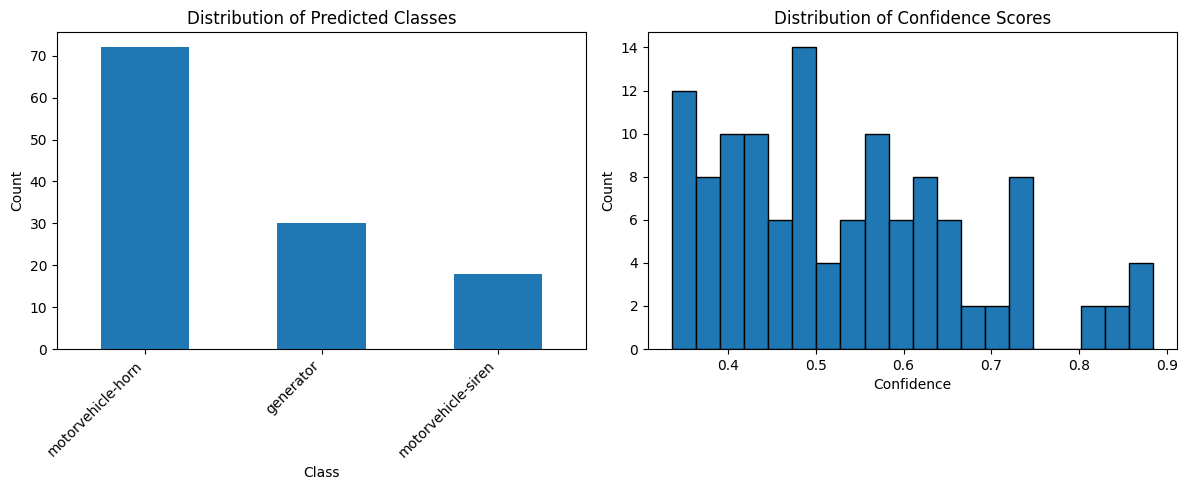

In [42]:
# Plot distribution of predictions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
results_df['predicted_class_name'].value_counts().plot(kind='bar')
plt.title('Distribution of Predicted Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.hist(results_df['confidence'], bins=20, edgecolor='black')
plt.title('Distribution of Confidence Scores')
plt.xlabel('Confidence')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Analyze Probability Vectors

Examine the probability distributions for predictions.

In [43]:
# Load probability matrix
_, prob_matrix, metadata = load_results(OUTPUT_DIR)

print(f"Probability matrix shape: {prob_matrix.shape}")
print(f"Number of files: {prob_matrix.shape[0]}")
print(f"Number of classes: {prob_matrix.shape[1]}")

Probability matrix shape: (120, 8)
Number of files: 120
Number of classes: 8


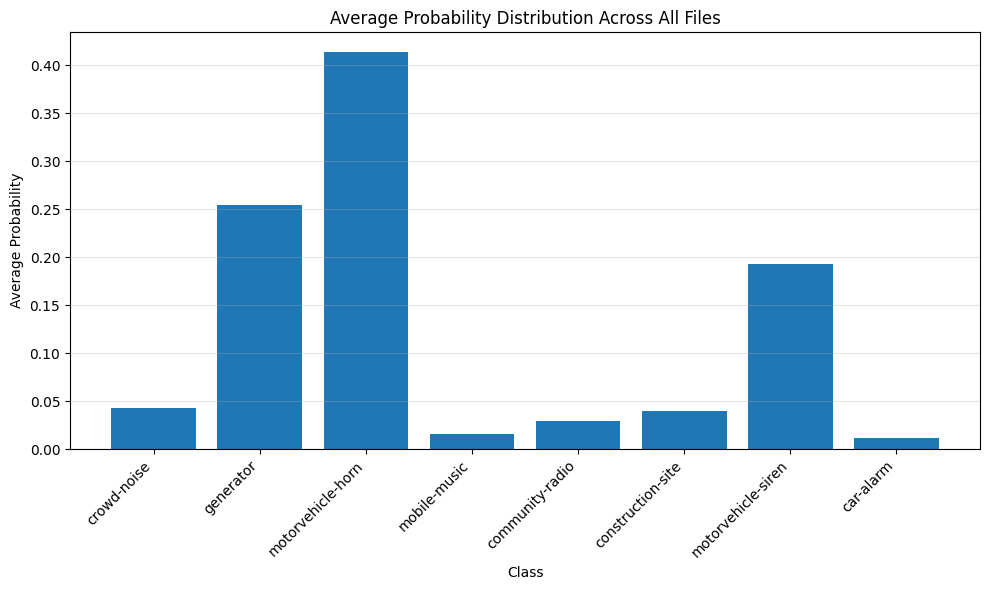

In [44]:
# Visualize average probability distribution across all predictions
avg_probs = prob_matrix.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.bar(CLASS_NAMES, avg_probs)
plt.title('Average Probability Distribution Across All Files')
plt.xlabel('Class')
plt.ylabel('Average Probability')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Examine Individual Predictions

In [45]:
# Show detailed results for files with low confidence
low_confidence = results_df[results_df['confidence'] < 0.5].sort_values('confidence')

if len(low_confidence) > 0:
    print("⚠️ Files with low confidence (<0.5):")
    print(low_confidence[['filename', 'predicted_class_name', 'confidence']].to_string())
else:
    print("✅ All predictions have confidence >= 0.5")

⚠️ Files with low confidence (<0.5):
                              filename predicted_class_name  confidence
7    test_traffic_vid_1_chunk_0003.wav   motorvehicle-siren    0.336310
6    test_traffic_vid_1_chunk_0003.wav   motorvehicle-siren    0.336310
102  test_traffic_vid_1_chunk_0051.wav   motorvehicle-siren    0.342388
103  test_traffic_vid_1_chunk_0051.wav   motorvehicle-siren    0.342388
84   test_traffic_vid_1_chunk_0042.wav   motorvehicle-siren    0.343437
85   test_traffic_vid_1_chunk_0042.wav   motorvehicle-siren    0.343437
107  test_traffic_vid_1_chunk_0053.wav    motorvehicle-horn    0.352005
106  test_traffic_vid_1_chunk_0053.wav    motorvehicle-horn    0.352005
40   test_traffic_vid_1_chunk_0020.wav    motorvehicle-horn    0.356163
41   test_traffic_vid_1_chunk_0020.wav    motorvehicle-horn    0.356163
58   test_traffic_vid_1_chunk_0029.wav    motorvehicle-horn    0.357793
59   test_traffic_vid_1_chunk_0029.wav    motorvehicle-horn    0.357793
83   test_traffic_vid_1_chu

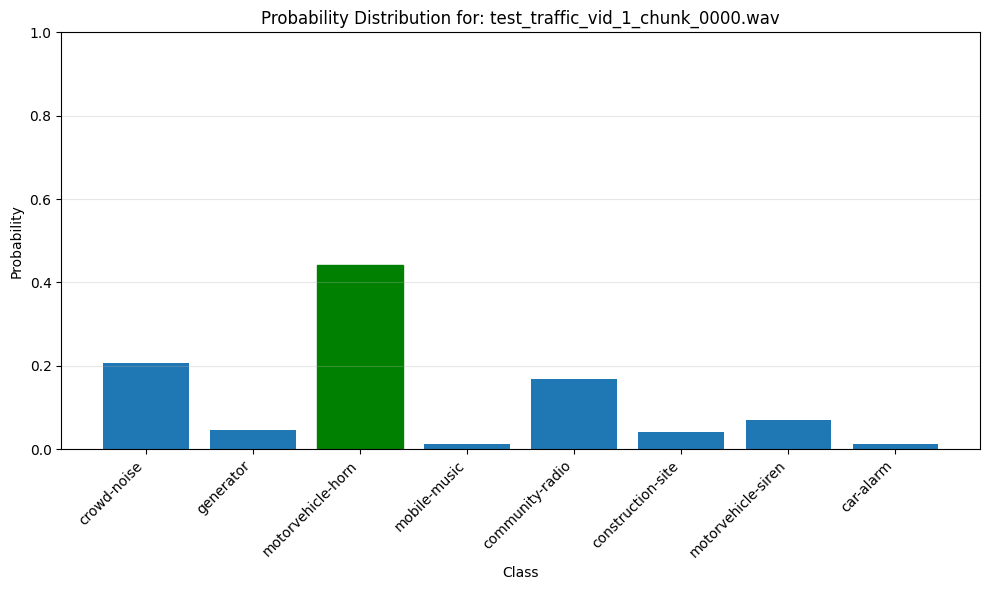


Predicted: motorvehicle-horn
Confidence: 0.4411


In [46]:
# Visualize probability distribution for a specific file
file_index = 0  # Change this to examine different files

if len(results_df) > 0:
    filename = results_df.iloc[file_index]['filename']
    probs = prob_matrix[file_index]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(CLASS_NAMES, probs)
    
    # Highlight predicted class
    predicted_idx = results_df.iloc[file_index]['predicted_class_id']
    bars[predicted_idx].set_color('green')
    
    plt.title(f'Probability Distribution for: {filename}')
    plt.xlabel('Class')
    plt.ylabel('Probability')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nPredicted: {results_df.iloc[file_index]['predicted_class_name']}")
    print(f"Confidence: {results_df.iloc[file_index]['confidence']:.4f}")

## 8. Process Single File (Optional)

Process a single audio file for testing.

In [47]:
# Example: Process a single file
# single_file_path = "path/to/your/audio/file.wav"
# result = processor.process_single_file(single_file_path)

# print("\nSingle file result:")
# print(f"File: {result['filename']}")
# print(f"Predicted: {result['predicted_class_name']}")
# print(f"Confidence: {result['confidence']:.4f}")
# print(f"\nProbability vector:")
# for i, class_name in enumerate(CLASS_NAMES):
#     print(f"  {class_name}: {result['probability_vector'][i]:.4f}")

## 9. Export Results for Further Analysis

In [48]:
# Save filtered results (e.g., only high-confidence predictions)
high_confidence = results_df[results_df['confidence'] >= 0.8]

output_path = Path(OUTPUT_DIR)
high_confidence.drop(columns=['probability_vector']).to_csv(
    output_path / 'high_confidence_predictions.csv',
    index=False
)

print(f"✅ Saved {len(high_confidence)} high-confidence predictions")

✅ Saved 8 high-confidence predictions


## Summary

This notebook demonstrated:
1. ✅ Loading a fine-tuned SpeechBrain model
2. ✅ Processing a directory of audio files in batches
3. ✅ Storing probability vectors for each prediction
4. ✅ Saving results in multiple formats (CSV, NumPy, JSON)
5. ✅ Analyzing and visualizing prediction results

### Output Files:
- `inference_results_<timestamp>.csv` - Predictions with class probabilities
- `probability_vectors_<timestamp>.npy` - NumPy array of probability vectors
- `metadata_<timestamp>.json` - Metadata including filenames and predictions